# FIAP TECH CHALLENGE 1 - GRUPO SSP

## 2. PRÉ-PROCESSAMENTO DOS DADOS

### 2.1. Estabelecendo a variável `BASE_PATH`

In [24]:
from pathlib import Path

# Considerando que o Notebook está sendo rodado em /src/notebooks/
BASE_PATH = Path.cwd().resolve().parent.parent
print(f"📁 Base path: {BASE_PATH.absolute()}")

📁 Base path: /Users/matias/Projetos/fiap/tech-challenge-1


### 2.2. Gerando um Dataframe único com todos os arquivos parquet concatenados

In [25]:
import pandas as pd

# Carregar todos os arquivos parquet do diretório
parquet_dir = BASE_PATH / "data" / "raw" / "VIOLBR24.parquet"

# Lista todos os arquivos .parquet no diretório
parquet_files = list(parquet_dir.glob("*.parquet"))
print(f"📊 Encontrados {len(parquet_files)} arquivos parquet")

# Carrega cada arquivo parquet e combina em um único dataframe
dfs = []
for parquet_file in parquet_files:
    df = pd.read_parquet(parquet_file)
    dfs.append(df)
    # print(f"✓ Carregado: {parquet_file.name} ({len(df)} linhas)")

# Concatena todos os dataframes
df_raw = pd.concat(dfs, ignore_index=True)
print(f"\n✅ DataFrame final criado com {len(df_raw)} linhas e {len(df_raw.columns)} colunas")

📊 Encontrados 23 arquivos parquet

✅ DataFrame final criado com 662803 linhas e 160 colunas


### 2.3. Analisando o dataframe resultando `df_raw`

In [26]:
# Visualização inicial do dataframe
print("📋 Informações do DataFrame:")
print(f"Shape: {df_raw.shape}")
print(f"\nColunas ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())
print(f"\nTipos de dados:")
print(df_raw.dtypes)
print(f"\nPrimeiras linhas:")
df_raw.head()

📋 Informações do DataFrame:
Shape: (662803, 160)

Colunas (160):
['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_UNIDADE', 'DT_OCOR', 'SEM_PRI', 'ANO_NASC', 'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI', 'ID_PAIS', 'NDUPLIC', 'DT_INVEST', 'ID_OCUPA_N', 'SIT_CONJUG', 'DEF_TRANS', 'DEF_FISICA', 'DEF_MENTAL', 'DEF_VISUAL', 'DEF_AUDITI', 'TRAN_MENT', 'TRAN_COMP', 'DEF_OUT', 'DEF_ESPEC', 'SG_UF_OCOR', 'ID_MN_OCOR', 'HORA_OCOR', 'LOCAL_OCOR', 'LOCAL_ESPE', 'OUT_VEZES', 'LES_AUTOP', 'VIOL_FISIC', 'VIOL_PSICO', 'VIOL_TORT', 'VIOL_SEXU', 'VIOL_TRAF', 'VIOL_FINAN', 'VIOL_NEGLI', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_OUTR', 'VIOL_ESPEC', 'AG_FORCA', 'AG_ENFOR', 'AG_OBJETO', 'AG_CORTE', 'AG_QUENTE', 'AG_ENVEN', 'AG_FOGO', 'AG_AMEACA', 'AG_OUTROS', 'AG_ESPEC', 'SEX_ASSEDI', 'SEX_ESTUPR', 'SEX_PUDOR', 'SEX_PORNO', 'SEX_EXPLO', 'SEX_OUTRO', 'SEX_ESPEC', 'PEN_ORAL', 'PEN_ANAL', 'PEN_VAGINA', 'PROC_DST', 'PROC_HIV', 'PROC_HEP

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,DT_OCOR,SEM_PRI,...,CONS_IDO,DELEG_IDOS,DIR_HUMAN,MPU,DELEG_CRIA,DELEG_MULH,DELEG,INFAN_JUV,DEFEN_PUBL,DT_ENCERRA
0,2,Y09,20240610,202424,2024,29,292740,0004081,20240418,202416,...,2,2,2,2,2,2,2,2,2,20240610
1,2,Y09,20240610,202424,2024,29,291920,2802023,20240602,202423,...,2,2,2,2,2,2,2,2,2,20240618
2,2,Y09,20240610,202424,2024,35,355030,2065266,20240610,202424,...,2,2,2,2,2,2,2,2,2,20240610
3,2,Y09,20240610,202424,2024,35,352070,2080362,20240610,202424,...,2,2,2,2,2,2,2,2,2,20240610
4,2,Y09,20240610,202424,2024,35,353440,0008036,20240604,202423,...,2,2,2,2,2,2,2,2,2,20240610


### 2.4. Aplicando filtros para delimitar escopo

Filtros Aplicados:
- Sexo Feminino
- Lesões que não sejam autoprovacadas

In [27]:
import numpy as np

def convert_col_to_binary(col, positive_value, negative_value):
    # Normalizar para lista: se for valor único, converte para lista
    positive_values = [positive_value] if not isinstance(positive_value, list) else positive_value
    negative_values = [negative_value] if not isinstance(negative_value, list) else negative_value
    
    # Criar uma nova Series com os valores convertidos
    result = col.copy()
    
    # Converter valores positivos para 1
    result[result.isin(positive_values)] = 1
    
    # Converter valores negativos para 0
    result[result.isin(negative_values)] = 0
    
    # Valores que não são positivos nem negativos ficam como NaN
    result[~result.isin([1, 0])] = np.nan
    
    return result

In [28]:
df_raw['IS_FEM'] = convert_col_to_binary(df_raw['CS_SEXO'], 'F', 'M')
df_raw['LES_AUTOP'] = convert_col_to_binary(df_raw['LES_AUTOP'], '1', '2')

In [29]:
print(df_raw['LES_AUTOP'].value_counts())

print(df_raw['IS_FEM'].value_counts())


LES_AUTOP
0    417185
1    194856
Name: count, dtype: int64
IS_FEM
1    463031
0    199590
Name: count, dtype: int64


In [30]:
filter = (
    (df_raw['IS_FEM'] == 1) &
    (df_raw['LES_AUTOP'] == 0)
)
df_filtered = df_raw[filter].copy()
print(df_filtered.shape)

(294393, 161)


### 2.5. Utilização de campos relevantes

Há cerca de 160 campos no dataset original vindo do DATASUS, dentre os quais cerca de 70 estão documentados no dicionário de dados mais atual ([Dicionário de Dados SINAN](../../docs/dicionario_dados_sinan.pdf)). Diante desse impasse, criamos um dicionário de dados próprio e preenchemos as informações de cada coluna e adicionamos o campo `relevante`. Caso verdadeiro, o campo será usado neste estudo. Essa estratégia foi usada pois há muitos campos redundantes etc.

In [31]:
import json

# Carregar o dicionário de campos
dicionario_path = BASE_PATH / "src" / "metadata" / "dicionario_campos_sinan.json"
with open(dicionario_path, 'r', encoding='utf-8') as f:
    dicionario = json.load(f)

# Filtrar campos com relevante = True
campos_relevantes = [
    campo for campo, info in dicionario.items() 
    if info.get('relevante', False) == True
]

# print(campos_relevantes)

# Filtrar apenas as colunas que existem no dataframe
colunas_existentes = [col for col in campos_relevantes if col in df_filtered.columns]
colunas_nao_existentes = [col for col in campos_relevantes if col not in df_filtered.columns]

if colunas_nao_existentes:
    print(f"\n⚠️  Aviso: {len(colunas_nao_existentes)} campos do dicionário não existem no dataframe:")
    print(colunas_nao_existentes)


# Criar subconjunto do dataframe com apenas as colunas relevantes
df_relevant = df_filtered[colunas_existentes].copy()

print(f"\n✅ DataFrame com campos relevantes criado:")
print(f"   Shape: {df_relevant.shape}")


✅ DataFrame com campos relevantes criado:
   Shape: (294393, 51)


### 2.6. Ajustando campos

#### 2.6.1. Criando campos para análise de dia da semana e mês do ano

In [32]:
df_relevant.loc[:,'DIA_SEMANA_OCOR'] = pd.to_datetime(df_relevant['DT_OCOR'].astype(str), format='%Y%m%d', errors='coerce').dt.dayofweek.map({0:'SEG',1:'TER',2:'QUA',3:'QUI',4:'SEX',5:'SAB',6:'DOM'})
df_relevant.loc[:,'MES_OCOR'] = pd.to_datetime(df_relevant['DT_OCOR'].astype(str), format='%Y%m%d', errors='coerce').dt.month.map({1:'JAN',2:'FEV',3:'MAR',4:'ABR',5:'MAI',6:'JUN',7:'JUL',8:'AGO',9:'SET',10:'OUT',11:'NOV',12:'DEZ'})

# print(df_relevant[['DT_OCOR','DIA_SEMANA_OCOR','MES_OCOR']].head())


print(df_relevant['DIA_SEMANA_OCOR'].value_counts())
print(df_relevant['MES_OCOR'].value_counts())

# remover os campos DT_OCOR
df_relevant = df_relevant.drop(columns=['DT_OCOR'])

DIA_SEMANA_OCOR
DOM    49752
SEG    46069
SAB    41862
SEX    39959
QUA    39377
TER    39159
QUI    38215
Name: count, dtype: int64
MES_OCOR
SET    26893
OUT    26549
JAN    26077
AGO    25359
DEZ    24863
JUN    24495
NOV    24393
MAR    24198
MAI    23146
FEV    23031
JUL    22722
ABR    22667
Name: count, dtype: int64


#### 2.6.3. Binarizar os campos de tipo de Violência

In [33]:
campos_violencia = [
    "VIOL_FINAN",
    "VIOL_FISIC",
    "VIOL_INFAN",
    "VIOL_LEGAL",
    "VIOL_NEGLI",
    "VIOL_OUTR",
    "VIOL_PSICO",
    "VIOL_SEXU",
    "VIOL_TORT",
    "VIOL_TRAF",
]

for campo in campos_violencia:
    df_relevant[campo] = convert_col_to_binary(df_relevant[campo], '1', '2')
for campo in campos_violencia:
    print(df_relevant[campo].value_counts())
    print('\n')

VIOL_FINAN
0    278530
1      9008
Name: count, dtype: int64


VIOL_FISIC
1    172437
0    118228
Name: count, dtype: int64


VIOL_INFAN
0    286961
1       731
Name: count, dtype: int64


VIOL_LEGAL
0    287056
1       442
Name: count, dtype: int64


VIOL_NEGLI
0    255468
1     34048
Name: count, dtype: int64


VIOL_OUTR
0    279177
1      6493
Name: count, dtype: int64


VIOL_PSICO
0    199553
1     88503
Name: count, dtype: int64


VIOL_SEXU
0    217812
1     70572
Name: count, dtype: int64


VIOL_TORT
0    280623
1      6568
Name: count, dtype: int64


VIOL_TRAF
0    287549
1       176
Name: count, dtype: int64




#### 2.6.4. Binarizar demais campos


- O campo de DEF_TRANS informa se o paciente possui algum tipo de deficiência/transtorno. Consideramos '1' para Sim e '0' Para Não ou Ignorado

In [34]:
campos_deficiencia = [
    "DEF_TRANS",
]

for campo in campos_deficiencia:
    df_relevant[campo] = convert_col_to_binary(df_relevant[campo], '1', ['2','8'])

    
for campo in campos_deficiencia:
    print(df_relevant[campo].value_counts())
    print('\n')
    

DEF_TRANS
0    232750
1     23384
Name: count, dtype: int64




#### 2.6.5. Preprocessar os campos de relacionamento do autor com a vítima

In [35]:
campos_relacao = [
    "REL_CONHEC",
    "REL_CONJ",
    "REL_CUIDA",
    "REL_DESCO",
    "REL_EXCON",
    "REL_EXNAM",
    "REL_FILHO",
    "REL_INST",
    "REL_IRMAO",
    "REL_MAD",
    "REL_MAE",
    "REL_NAMO",
    "REL_OUTROS",
    "REL_PAD",
    "REL_PAI",
    "REL_PATRAO",
    "REL_POL",
    "REL_PROPRI",
    "REL_TRAB"
]

# for campo in campos_relacao:
#     print(df_relevant[campo].value_counts())
#     print('\n')


for campo in campos_relacao:
    df_relevant[campo] = convert_col_to_binary(df_relevant[campo], '1', '2')


# Função para aglomerar os campos de relacionamento
def flag_any(df, cols):
    cols = [c for c in cols if c in df.columns]
    block = df[cols].apply(pd.to_numeric, errors="coerce")  # força numérico
    return block.fillna(0).astype("int8").any(axis=1).astype("int8")


# --- Grupos semânticos de relacionamento ---

grupo_parceiro_intimo = [
    "REL_CONJ", "REL_EXCON", "REL_NAMO", "REL_EXNAM"
]

grupo_familiar = [
    "REL_PAI", "REL_MAE", "REL_PAD", "REL_MAD", "REL_IRMAO", "REL_FILHO"
]

grupo_conhecido = [
    "REL_CONHEC", "REL_CUIDA", "REL_DESCO"
]

grupo_institucional = [
    "REL_PATRAO", "REL_TRAB", "REL_INST", "REL_POL", "REL_PROPRI"
]

grupo_outros = [
    "REL_OUTROS"
]

df_relevant["REL_PARCEIRO_INTIMO"] = flag_any(df_relevant, grupo_parceiro_intimo)
df_relevant["REL_FAMILIAR"] = flag_any(df_relevant, grupo_familiar)
df_relevant["REL_CONHECIDO"] = flag_any(df_relevant, grupo_conhecido)
df_relevant["REL_INSTITUCIONAL"] = flag_any(df_relevant, grupo_institucional)
df_relevant["REL_OUTROS_FLAG"] = flag_any(df_relevant, grupo_outros)

# remover os campos de relacionamento
df_relevant = df_relevant.drop(columns=campos_relacao)

campos_relacao_agregados = [
    "REL_PARCEIRO_INTIMO",
    "REL_FAMILIAR",
    "REL_CONHECIDO",
    "REL_INSTITUCIONAL",
    "REL_OUTROS_FLAG"
]

for campo in campos_relacao_agregados:
    print(df_relevant[campo].value_counts())
    print('\n')




REL_PARCEIRO_INTIMO
0    183293
1    111100
Name: count, dtype: int64


REL_FAMILIAR
0    223215
1     71178
Name: count, dtype: int64


REL_CONHECIDO
0    226961
1     67432
Name: count, dtype: int64


REL_INSTITUCIONAL
0    280747
1     13646
Name: count, dtype: int64


REL_OUTROS_FLAG
0    265909
1     28484
Name: count, dtype: int64




#### 2.6.6. Preprocessar os campos de meio de agressão (AG_*)

In [36]:
campos_agressao = [
    "AG_AMEACA",
    "AG_CORTE",
    "AG_ENFOR",
    "AG_ENVEN",
    "AG_FOGO",
    "AG_FORCA",
    "AG_OBJETO",
    "AG_OUTROS",
    "AG_QUENTE"
]

for campo in campos_agressao:
    df_relevant[campo] = convert_col_to_binary(df_relevant[campo], '1', '2')


for campo in campos_agressao:
    print(df_relevant[campo].value_counts())
    print('\n')





AG_AMEACA
0    213212
1     68460
Name: count, dtype: int64


AG_CORTE
0    264950
1     16899
Name: count, dtype: int64


AG_ENFOR
0    265255
1     16507
Name: count, dtype: int64


AG_ENVEN
0    277106
1      4281
Name: count, dtype: int64


AG_FOGO
0    277297
1      4180
Name: count, dtype: int64


AG_FORCA
1    164797
0    120160
Name: count, dtype: int64


AG_OBJETO
0    267754
1     13726
Name: count, dtype: int64


AG_OUTROS
0    229617
1     47517
Name: count, dtype: int64


AG_QUENTE
0    279476
1      2071
Name: count, dtype: int64




#### 2.6.7. Obter sigla do Estado pelo código do IBGE

In [37]:

# Carregar o dicionário de estados
dicionario_estados_path = BASE_PATH / "src" / "metadata" / "dicionario_estados_ibge.json"
with open(dicionario_estados_path, 'r', encoding='utf-8') as f:
    dicionario_estados = json.load(f)

# Criar um dicionário de conversão: código numérico -> sigla da UF
# print(dicionario_estados)

# Converter com tratamento de valores não encontrados
df_relevant['SG_UF'] = df_relevant['SG_UF'].astype(str).map(dicionario_estados).apply(lambda x: x if str(x).strip() != '' else np.nan)

print(df_relevant['SG_UF'].value_counts())


SG_UF
SP    73761
RJ    36825
PR    27538
MG    24730
RS    16381
CE    14031
PE    13059
BA    10807
SC     9780
GO     9075
ES     8590
PA     8306
MS     6043
AM     5503
AL     4458
DF     3724
MA     3008
MT     2956
PI     2954
TO     2819
SE     2226
PB     2211
RN     1988
RR     1161
RO     1062
AC      866
AP      497
Name: count, dtype: int64


#### 2.6.8. Ajustando os demais campos

In [38]:
# ORIENT_SEX
df_relevant['ORIENT_SEX'] = df_relevant['ORIENT_SEX'].map({'1':'Heterossexual','2':'Homossexual','3':'Bissexual','8':'Não se aplica','9':'Ignorado'}).apply(lambda x: x if str(x).strip() != '' else np.nan)
# OUT_VEZES

df_relevant['OUT_VEZES'] = convert_col_to_binary(df_relevant['OUT_VEZES'], '1', '2').apply(lambda x: x if str(x).strip() != '' else np.nan)

# AUTOR_ALC
df_relevant['AUTOR_ALCO'] = convert_col_to_binary(df_relevant['AUTOR_ALCO'], '1', '2')

#AUTOR_SEXO
df_relevant['AUTOR_SEXO'] = df_relevant['AUTOR_SEXO'].map({'1':'Masculino','2':'Feminino','3':'Ambos','9':'Ignorado'}).apply(lambda x: x if str(x).strip() != '' else np.nan)

# CICL_VID
df_relevant['CICL_VID'] = df_relevant['CICL_VID'].map({'1':'Criança','2':'Adolescente','3':'Jovem','4':'Pessoa adulta','5':'Pessoa idosa','9':'Ignorado'}).apply(lambda x: x if str(x).strip() != '' else np.nan)

# CIRC_LESAO
# retirar nan
df_relevant['CIRC_LESAO'] = df_relevant['CIRC_LESAO'].dropna().apply(lambda x: x if str(x).strip() != '' else np.nan)

# CS_RACA - mapear
df_relevant['CS_RACA'] = df_relevant['CS_RACA'].map({'1':'Branca','2':'Preta','3':'Amarela','4':'Parda','5':'Indígena','9':'Ignorado'}).apply(lambda x: x if str(x).strip() != '' else np.nan)

# IDENT_GEN - mapear
df_relevant['IDENT_GEN'] = df_relevant['IDENT_GEN'].map({'1':'Travesti','2':'Transexual Mulher','3':'Transexual Homem','8':'Não se aplica','9':'Ignorado'}).apply(lambda x: x if str(x).strip() != '' else np.nan)

# SIT_CONJUG - mapear
df_relevant['SIT_CONJUG'] = df_relevant['SIT_CONJUG'].map({'1':'Solteiro','2':'Casado/ União','3':'Viúvo','4':'Separado','8':'Não se aplica'}).apply(lambda x: x if str(x).strip() != '' else np.nan)


#### 2.6.9. Mapear campos para facilitar leitura



In [39]:
# Criar categoria sucinta de escolaridade a partir de CS_ESCOL_N
# Grupos:
# 0 = Baixa escolaridade (analfabeto + fundamental incompleto)
# 1 = Fundamental completo / Médio incompleto
# 2 = Médio completo
# 3 = Superior (incompleto ou completo)
# NaN = Ignorado / Não se aplica / outros
df_relevant["CS_ESCOL_N"] = pd.to_numeric(df_relevant["CS_ESCOL_N"], errors="coerce")

# Usar pandas.loc que é mais flexível
df_relevant["ESCOLARIDADE"] = None  # Inicializar com NaN

df_relevant.loc[df_relevant["CS_ESCOL_N"].isin([43, 1, 2, 3]), "ESCOLARIDADE"] = 'FUNDAMENTAL_INCOMPLETO'
df_relevant.loc[df_relevant["CS_ESCOL_N"].isin([4, 5]), "ESCOLARIDADE"] = 'ENSINO_MEDIO_INCOMPLETO'
df_relevant.loc[df_relevant["CS_ESCOL_N"] == 6, "ESCOLARIDADE"] = 'ENSINO_MEDIO_COMPLETO'
df_relevant.loc[df_relevant["CS_ESCOL_N"].isin([7, 8]), "ESCOLARIDADE"] = 'ENSINO_SUPERIOR'

# remover o campo CS_ESCOL_N
df_relevant = df_relevant.drop(columns=['CS_ESCOL_N'])

print(df_relevant['ESCOLARIDADE'].value_counts())


ESCOLARIDADE
FUNDAMENTAL_INCOMPLETO     66213
ENSINO_MEDIO_COMPLETO      53551
ENSINO_MEDIO_INCOMPLETO    44007
ENSINO_SUPERIOR            21039
Name: count, dtype: int64


#### 2.6.10. Agrupar campos de CIRC_LESAO em CIRC_LESAO_FAMILIA

Aqui vamos realizar um procedimento para agrupar CIDs de subcategorias na mesma categoria. Esperamos assim conseguir um distribuição de frequência menos esparsa.

In [40]:
print(df_relevant['CIRC_LESAO'].value_counts().head(20))

# normaliza e extrai a família (ex.: Y04.0 -> Y04)
s = df_relevant["CIRC_LESAO"].astype(str).str.strip()
df_relevant["CIRC_LESAO_FAMILIA"] = np.where(
    s.isin(["", "nan", "None"]), np.nan,
    s.str.upper().str.extract(r"^([A-Z]\d{2})", expand=False)
)

print(df_relevant['CIRC_LESAO_FAMILIA'].value_counts())

# remover o campo CIRC_LESAO
df_relevant = df_relevant.drop(columns=['CIRC_LESAO'])


CIRC_LESAO
Y04      20309
Y04.0    18976
Y09      12325
Y05.0     7183
Y05       6128
Y06.1     6041
T74.2     4595
Y04.4     3526
Y04.9     3012
Y07.0     2599
T74.3     2267
Y08.0     1941
Y07.8     1806
Y06       1745
X99       1449
Y05.4     1293
Y05.9     1262
Y06.8     1250
Y04.5     1150
Y07       1117
Name: count, dtype: int64
CIRC_LESAO_FAMILIA
Y04    48731
Y05    17384
Y09    12798
Y06     9809
T74     8111
       ...  
S64        1
P12        1
A53        1
W78        1
V06        1
Name: count, Length: 582, dtype: int64


### 2.7. Distribuição de Valores

Nesta etapa analisamos a distribuição dos valores de cada um dos campos remanescentes a fim de verificar quais deles são elegíveis para serem utilizados em nosso estudo.

LEGENDA:
Para a maioria das respostas:
1. Sim
2. Não
9. Ignorado 

Orientação Sexual: 
1. Heterossexual
2. Homossexual
(gay/lésbica)
3. Bissexual
8. Não se aplica
9. Ignorado

Autor_Sexo:
1. Masculino
2. Feminino
3. Ambos os sexos
9. Ignorado

Identidade de Gênero:
1. Travesti
2. Transexual Mulher
3. Transexual Homem
8. Não se aplica
9. Ignorado

Motivo da Violência:
01. Sexismo
02. Homofobia/Lesbofobia
Bifobia/Transfobia
03. Racismo
04. Intolerância religiosa
05. Xenofobia
06. Conflito geracional
07. Situação de rua
08. Deficiência
09. Outros
88. Não se aplica
99. Ignorado

Escolaridade:
1. 1ª a 4ª série incompleta do
EF
2. 4ª série completa do EF (
antigo 1° grau)
3. 5ª à 8ª série incompleta do
EF (antigo ginásio ou 1°
grau)
4. Ensino fundamental
completo (antigo ginásio ou
1° grau)
5. Ensino médio incompleto
(antigo colegial ou 2° grau)
6. Ensino médio completo
(antigo colegial ou 2° grau)
7. Educação superior
incompleta
8. Educação superior
completa
9. Ignorado
10. Não se aplica


Raça: 
1- branca
2- preta
3- amarela
4- parda
5- indígena
9 Ignorado

Deficiências:
1. Sim
2. Não
8. Não se aplica
9. Ignorado


#### 2.7.1. Salvar o dataframe pré-processado

In [41]:
df_preprocessed = df_relevant.dropna()

print(f'Quantidade de colunas: {len(df_preprocessed.columns)}')

df_preprocessed.to_parquet(BASE_PATH / "data" / "processed" / "df_preprocessed.parquet")

Quantidade de colunas: 38


### 2.8. Análise das colunas

Temos 38 colunas após o preprocessamento do dataset original (`df_raw`).

**Grupo de Agravo (AG_*):** AG_AMEACA, AG_CORTE, AG_ENFOR, AG_ENVEN, AG_FOGO, AG_FORCA, AG_OBJETO, AG_OUTROS, AG_QUENTE (9 campos)

**Grupo de Autor:** AUTOR_ALCO, AUTOR_SEXO (2 campos)

**Grupo de Características da Vítima:** CICL_VID, CS_RACA, IDENT_GEN, ORIENT_SEX, SIT_CONJUG, ESCOLARIDADE (6 campos)

**Grupo de Circunstância/Lesão:** CIRC_LESAO_FAMILIA (1 campos)

**Grupo de Deficiência:** DEF_TRANS (1 campo)

**Grupo de Localização:** SG_UF (1 campo)

**Grupo de Violência (VIOL_*):** VIOL_FINAN, VIOL_FISIC, VIOL_INFAN, VIOL_LEGAL, VIOL_NEGLI, VIOL_OUTR, VIOL_PSICO, VIOL_SEXU, VIOL_TORT, VIOL_TRAF (10 campos)

**Grupo de Relação (REL_*):** REL_PARCEIRO_INTIMO, REL_FAMILIAR, REL_CONHECIDO, REL_INSTITUCIONAL, REL_OUTROS_FLAG (5 campos)

**Grupo de Tempo:** DIA_SEMANA_OCOR, MES_OCOR (2 campos)

**Grupo de Variável Alvo:** OUT_VEZES (1 campo)

In [42]:
import pandas as pd
from IPython.display import display

# Criar lista com distribuição de cada coluna como string
distribuicoes = []
for col in df_preprocessed.columns:
    vc = df_preprocessed[col].value_counts(dropna=False)
    # Formatar como string: "valor1: count1, valor2: count2, ..."
    dist_str = ', '.join([f"{k}: {v}" for k, v in vc.head(10).items()])  # top 10
    if len(vc) > 10:
        dist_str += f" ... (+{len(vc) - 10} outros)"
    distribuicoes.append(dist_str)

tb_df = pd.DataFrame({
    'coluna': df_preprocessed.columns,
    'n_categorias': df_preprocessed.nunique().values,
    'distribuição': distribuicoes
},index=range(len(df_preprocessed.columns)))


display(tb_df)

,coluna,n_categorias,distribuição
0,AG_AMEACA,2,"0: 40787, 1: 16235"
1,AG_CORTE,2,"0: 53330, 1: 3692"
2,AG_ENFOR,2,"0: 52685, 1: 4337"
3,AG_ENVEN,2,"0: 56311, 1: 711"
4,AG_FOGO,2,"0: 56356, 1: 666"
5,AG_FORCA,2,"1: 38070, 0: 18952"
6,AG_OBJETO,2,"0: 53888, 1: 3134"
7,AG_OUTROS,2,"0: 49683, 1: 7339"
8,AG_QUENTE,2,"0: 56731, 1: 291"
9,AUTOR_ALCO,2,"0: 33485, 1: 23537"


### 2.9. Plotando a distribuição de valores dos campos pré-processados

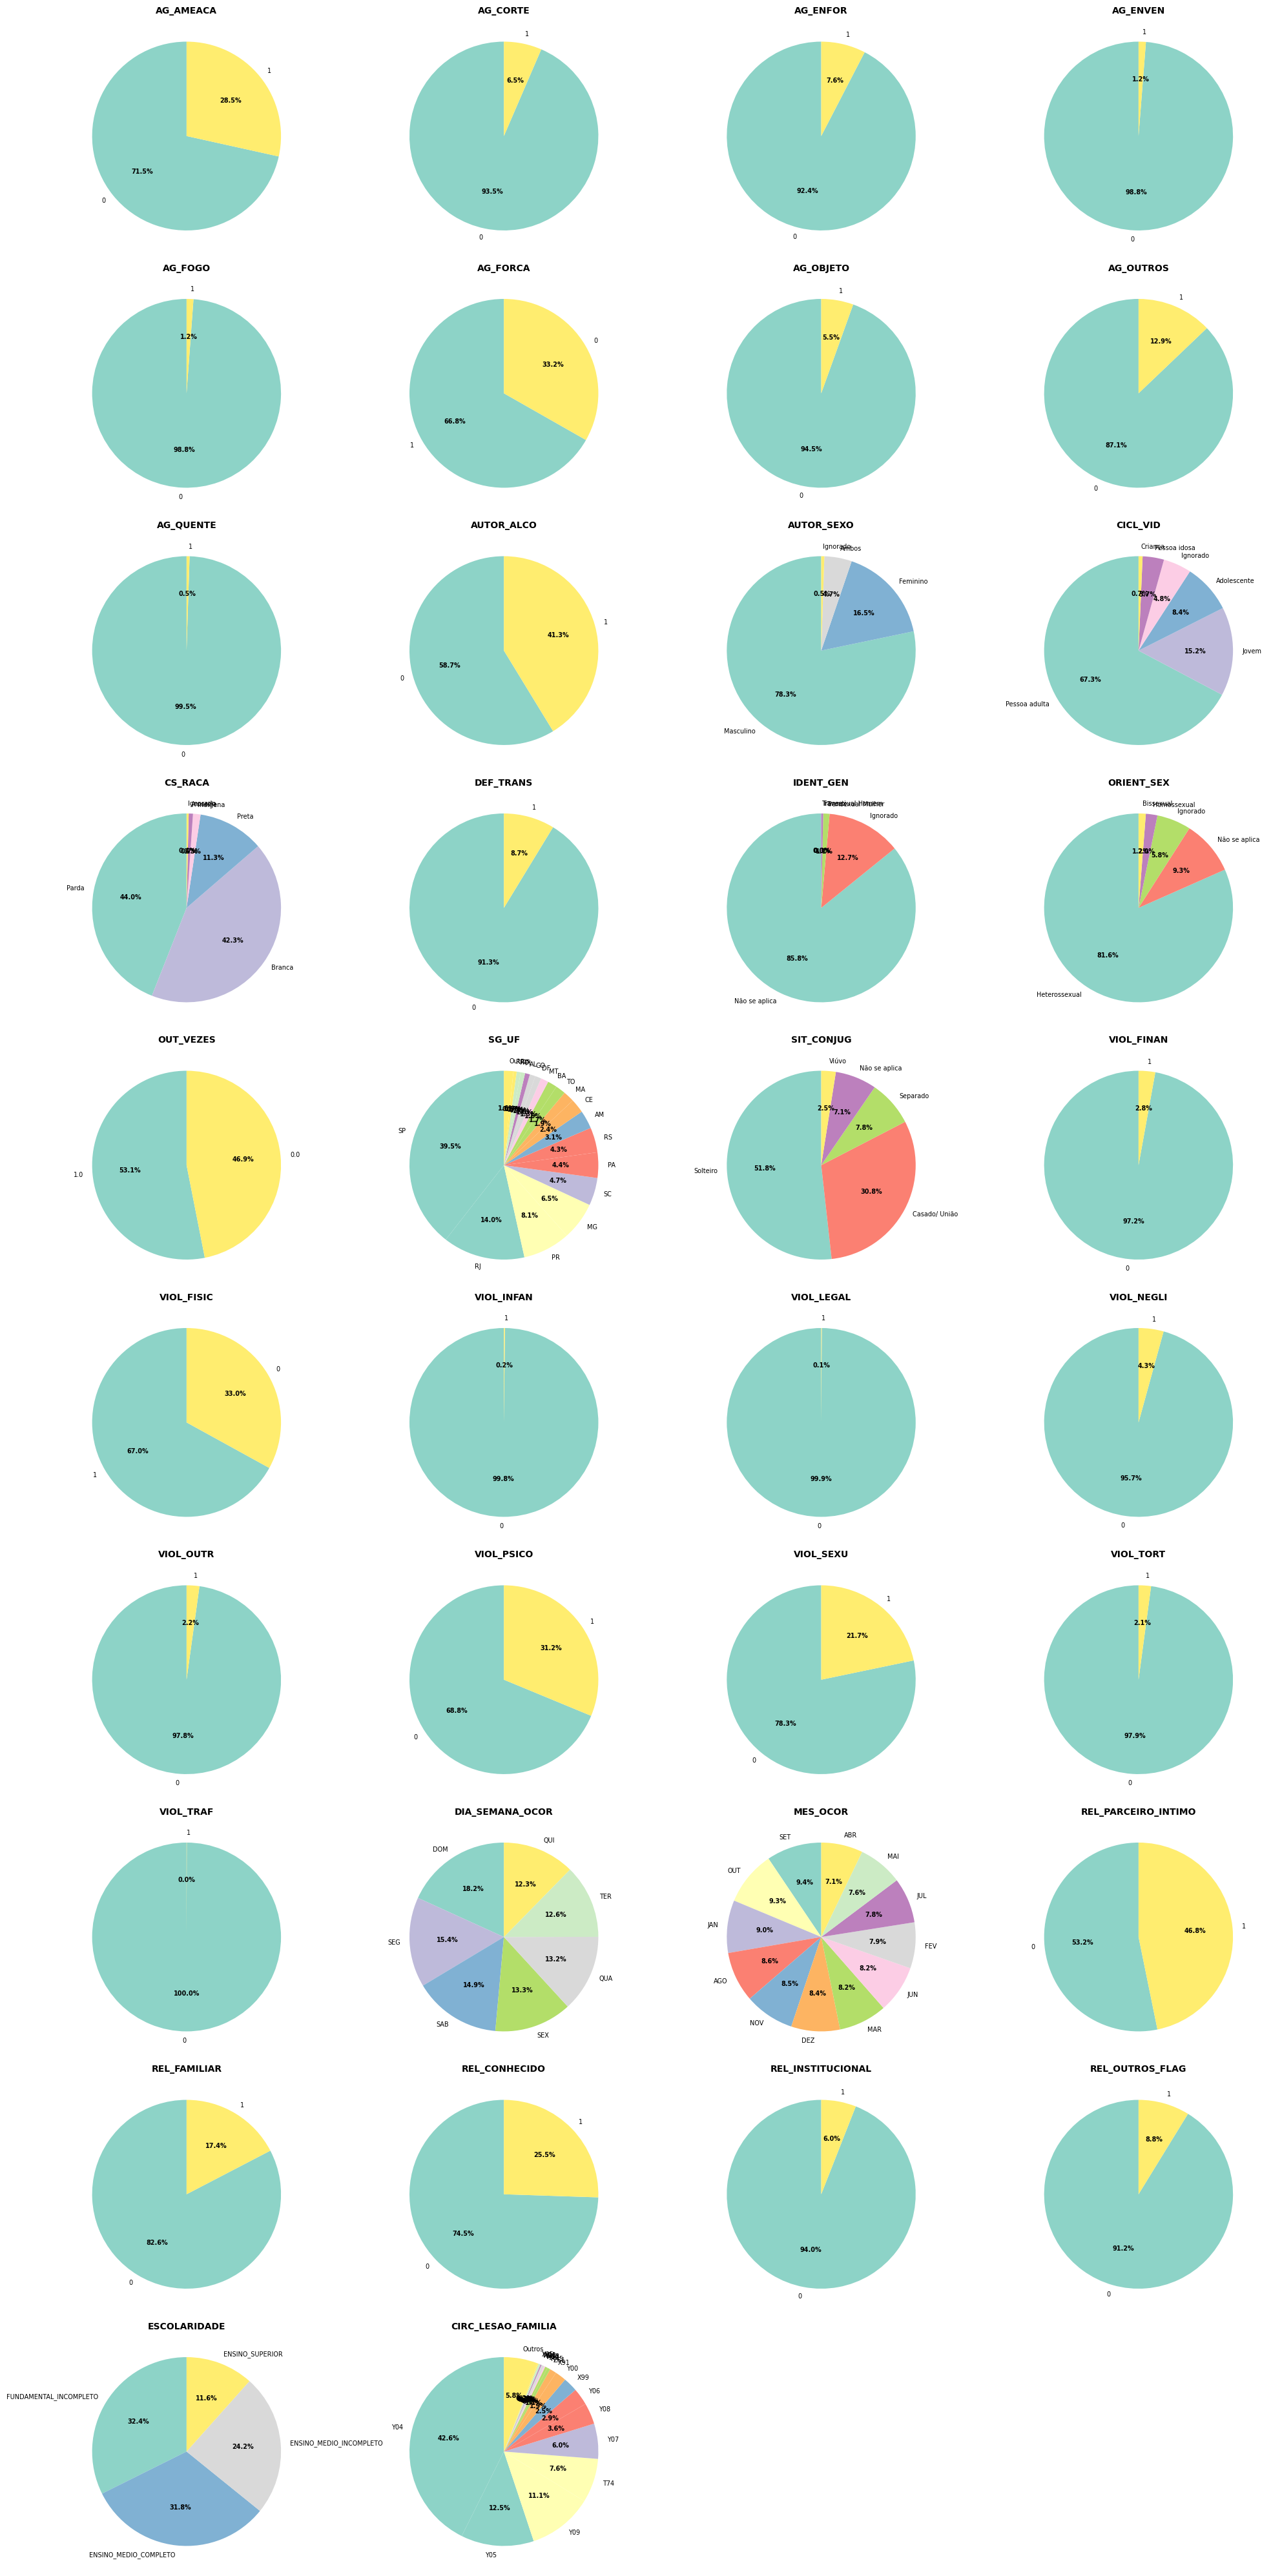

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar o grid de 5 colunas
n_cols = 4
n_cols_total = len(df_preprocessed.columns)
n_rows = int(np.ceil(n_cols_total / n_cols))

# Criar figura com tamanho adequado
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols_total == 1 else axes

# Para cada coluna, criar um gráfico de pizza
for idx, col in enumerate(df_preprocessed.columns):
    ax = axes[idx]
    
    # Obter contagem de valores
    value_counts = df_preprocessed[col].value_counts(dropna=False)
    
    # Se houver muitas categorias, limitar aos top 10 e agrupar o resto
    max_categories = 20
    if len(value_counts) > max_categories:
        top_values = value_counts.head(max_categories - 1)
        others_sum = value_counts.tail(len(value_counts) - (max_categories - 1)).sum()
        value_counts = pd.concat([top_values, pd.Series({'Outros': others_sum})])
    
    # Criar gráfico de pizza
    colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))
    wedges, texts, autotexts = ax.pie(
        value_counts.values,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 8}
    )
    
    # Ajustar tamanho da fonte dos labels
    for text in texts:
        text.set_fontsize(7)
    for autotext in autotexts:
        autotext.set_fontsize(7)
        autotext.set_color('black')
        autotext.set_weight('bold')
    
    # Título com nome da coluna
    ax.set_title(col, fontsize=10, fontweight='bold', pad=5)

# Ocultar eixos extras se houver
for idx in range(n_cols_total, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()